## CSV 7: Extreme Outliers, Refunds & Negative Revenue

**Description**  
A sales dataset containing financial anomalies including extreme high-value enterprise deals, refunds and chargebacks (negative revenue), zero-revenue transactions, and highly variable deal sizes.

**Purpose / What It Tests**
- Detection and treatment of outliers and anomalies
- Robust aggregation choices (median vs. mean)
- Correct handling of negative and zero revenue
- Clear explanation of anomaly impact on KPIs
- Evaluation of decision-quality, not just correctness


Dataset Generation

In [1]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

np.random.seed(99)

N_ROWS = 2700

start_date = datetime(2023, 1, 1)
end_date = datetime(2024, 12, 31)

def random_date():
    return start_date + timedelta(days=random.randint(0, (end_date - start_date).days))

products = [
    (101, "CRM Pro", "Software"),
    (102, "Analytics Suite", "Software"),
    (103, "Sales Booster", "Software"),
    (201, "POS Terminal", "Hardware"),
]

regions = ["North America", "Europe", "Asia"]
salespeople = [f"Salesperson_{i}" for i in range(1, 12)]

rows = []

for i in range(N_ROWS):
    product_id, product_name, category = random.choice(products)
    units = random.randint(1, 15)
    base_price = random.randint(200, 1500)

    revenue = units * base_price

    # Inject refunds (negative revenue)
    if random.random() < 0.08:
        revenue = -revenue

    # Inject extreme enterprise deals
    if random.random() < 0.05:
        revenue *= random.randint(20, 80)

    # Inject zero-revenue promos
    if random.random() < 0.04:
        revenue = 0

    rows.append({
        "order_id": f"O-{700000+i}",
        "order_date": random_date(),
        "customer_id": f"C-{random.randint(1000, 6000)}",
        "product_id": product_id,
        "product_name": product_name,
        "category": category,
        "units": units,
        "revenue": revenue,
        "region": random.choice(regions),
        "salesperson": random.choice(salespeople),
        "stage": "Won"
    })

df = pd.DataFrame(rows)

df.to_csv("sales_outliers_refunds.csv", index=False)
print("CSV generated: sales_outliers_refunds.csv")


CSV generated: sales_outliers_refunds.csv


Validation Code

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("sales_outliers_refunds.csv")

# Negative revenue check
negative_count = (df["revenue"] < 0).sum()
zero_count = (df["revenue"] == 0).sum()

print("Negative revenue rows:", negative_count)
print("Zero revenue rows:", zero_count)

assert negative_count > 0, "❌ No refunds detected"
assert zero_count > 0, "❌ No zero-revenue deals detected"

# Outlier detection using IQR
q1 = df["revenue"].quantile(0.25)
q3 = df["revenue"].quantile(0.75)
iqr = q3 - q1

outliers = df[(df["revenue"] > q3 + 3 * iqr)]
print("Extreme outlier rows:", len(outliers))

assert len(outliers) > 0, "❌ No extreme outliers detected"

# Skewness check
skewness = df["revenue"].skew()
print("Revenue skewness:", skewness)

assert abs(skewness) > 1, "❌ Distribution not skewed enough"

print("✅ Outlier & refund conditions validated.")


Negative revenue rows: 177
Zero revenue rows: 95
Extreme outlier rows: 113
Revenue skewness: 4.489005245938803
✅ Outlier & refund conditions validated.


Gold Truth Analysis

Gross Revenue: 54955832
Refunds (Negative): -6146786
Net Revenue: 48809046
Refund Rate: 0.06555555555555556


C:\Users\KRONOS\AppData\Local\Temp\ipykernel_24896\1505509135.py:29: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["revenue"]


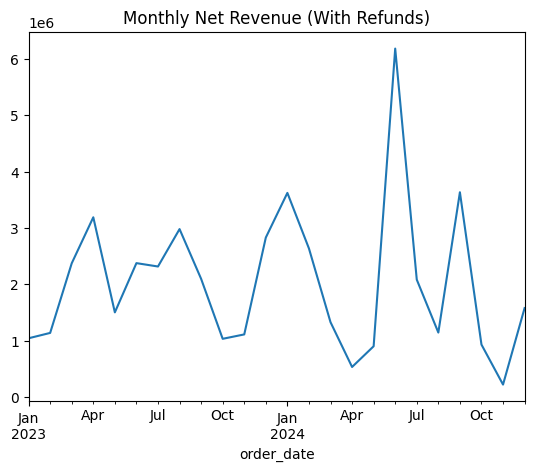

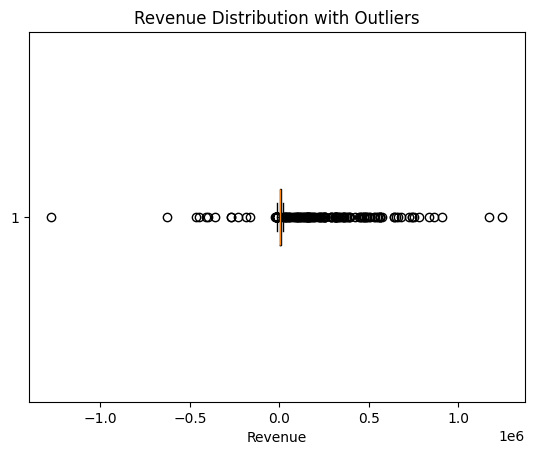

C:\Users\KRONOS\AppData\Local\Temp\ipykernel_24896\1505509135.py:49: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["revenue"]


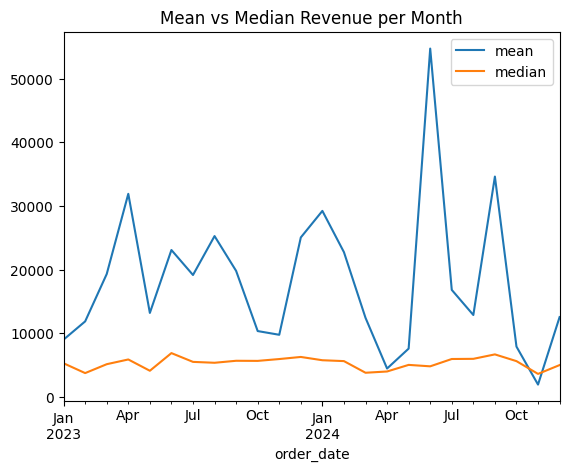

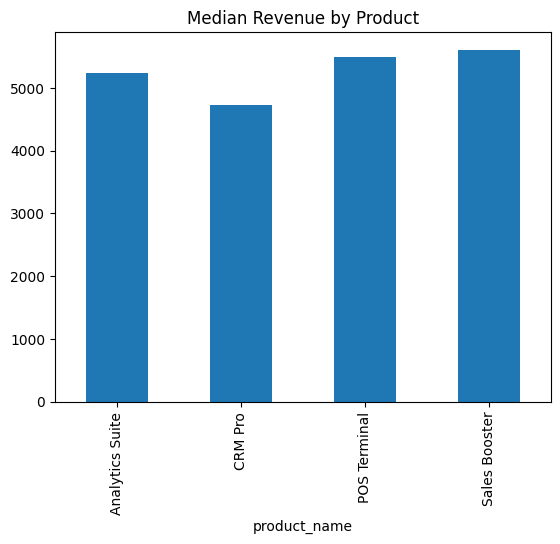

Revenue Share from Top 5% Deals: 0.8116301023379969


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("sales_outliers_refunds.csv", parse_dates=["order_date"])

# ---------------------------
# KPI 1: Gross vs Net Revenue
# ---------------------------
gross_revenue = df[df["revenue"] > 0]["revenue"].sum()
refunds = df[df["revenue"] < 0]["revenue"].sum()
net_revenue = df["revenue"].sum()

print("Gross Revenue:", gross_revenue)
print("Refunds (Negative):", refunds)
print("Net Revenue:", net_revenue)

# ---------------------------
# KPI 2: Refund Rate
# ---------------------------
refund_rate = (df["revenue"] < 0).mean()
print("Refund Rate:", refund_rate)

# ---------------------------
# Trend 1: Monthly Net Revenue
# ---------------------------
monthly_net = (
    df.set_index("order_date")
      .resample("M")["revenue"]
      .sum()
)

monthly_net.plot(title="Monthly Net Revenue (With Refunds)")
plt.show()

# ---------------------------
# Trend 2: Revenue Distribution (Boxplot)
# ---------------------------
plt.boxplot(df["revenue"], vert=False)
plt.title("Revenue Distribution with Outliers")
plt.xlabel("Revenue")
plt.show()

# ---------------------------
# Trend 3: Median vs Mean Revenue Over Time
# ---------------------------
monthly_stats = (
    df.set_index("order_date")
      .resample("M")["revenue"]
      .agg(["mean", "median"])
)

monthly_stats.plot(title="Mean vs Median Revenue per Month")
plt.show()

# ---------------------------
# Trend 4: Revenue by Product (Median)
# ---------------------------
median_revenue_product = df.groupby("product_name")["revenue"].median()
median_revenue_product.plot(kind="bar", title="Median Revenue by Product")
plt.show()

# ---------------------------
# KPI 3: % Revenue from Top 5% Deals
# ---------------------------
threshold = df["revenue"].quantile(0.95)
top_deals_share = df[df["revenue"] >= threshold]["revenue"].sum() / net_revenue
print("Revenue Share from Top 5% Deals:", top_deals_share)
